<a href="https://colab.research.google.com/github/LeninGF/IAG-2024B-GenerativeQA/blob/main/dataset_build.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

- Coder: Lenin G. Falconi

## Goal:

- To format dataset in question, answer and context
- To use some LLM in order to retrieve or build questions from the data



In [29]:
# # For Colab
# !pip install python-dotenv
# !pip install huggingface_hub
# !pip install datasets

In [30]:
# # For Colab
# from dotenv import load_dotenv
# import os
# dotenv_path = '/content/.env'
# load_dotenv(dotenv_path)

In [31]:
import os
from huggingface_hub import login
token = os.getenv('HUGGINGFACE_TOKEN')
login(token)

In [32]:
from datasets import load_dataset
dataset_path = 'LeninGF/autotrain-data-robberyclassification'
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset(dataset_path)

In [33]:
from pprint import pprint
pprint(ds['train'][100])

{'labels': 'ROBO A DOMICILIO',
 'relato': 'es el caso señor fiscal que el día 17 de agosto del 2018 '
           'aproximadamente a las 11h00 salí de mi domicilio ubicado en la '
           'cooperativa 8 de marzo calle n pasaje e20j lote 3 número s8 45 '
           'sector puente dos autopista general rumiñahui a realizar una '
           'gestión de pagos al retornar a las 13h20 pude observar que tres '
           'sujetos salían de mi domicilio y afuera ase encontraba estacionado '
           'un automóvil al ingresar me percate que me habías sustraído dos '
           'televisores marca lg 4k de 65 pulgadas un televisor marca samsung '
           'hd de 32 pulgadas un play station pro 1tb un nintendo switch '
           'cuatro whisky un lote de joyas de plata y oro valorado en 3 450 '
           'dolares y 40 dólares en efectivo motivo por la cual pongo la '
           'respectiva denuncia con la finalidad de que se realicen las '
           'investigaciones del caso más informaci

## Word count per Text Histogram

In [34]:
def count_words(sample):
    sample['word_count'] = len(sample['relato'].split())
    return sample

ds = ds.map(count_words, batched=False)

In [36]:
pprint(ds['train'][100])

{'labels': 'ROBO A DOMICILIO',
 'relato': 'es el caso señor fiscal que el día 17 de agosto del 2018 '
           'aproximadamente a las 11h00 salí de mi domicilio ubicado en la '
           'cooperativa 8 de marzo calle n pasaje e20j lote 3 número s8 45 '
           'sector puente dos autopista general rumiñahui a realizar una '
           'gestión de pagos al retornar a las 13h20 pude observar que tres '
           'sujetos salían de mi domicilio y afuera ase encontraba estacionado '
           'un automóvil al ingresar me percate que me habías sustraído dos '
           'televisores marca lg 4k de 65 pulgadas un televisor marca samsung '
           'hd de 32 pulgadas un play station pro 1tb un nintendo switch '
           'cuatro whisky un lote de joyas de plata y oro valorado en 3 450 '
           'dolares y 40 dólares en efectivo motivo por la cual pongo la '
           'respectiva denuncia con la finalidad de que se realicen las '
           'investigaciones del caso más informaci

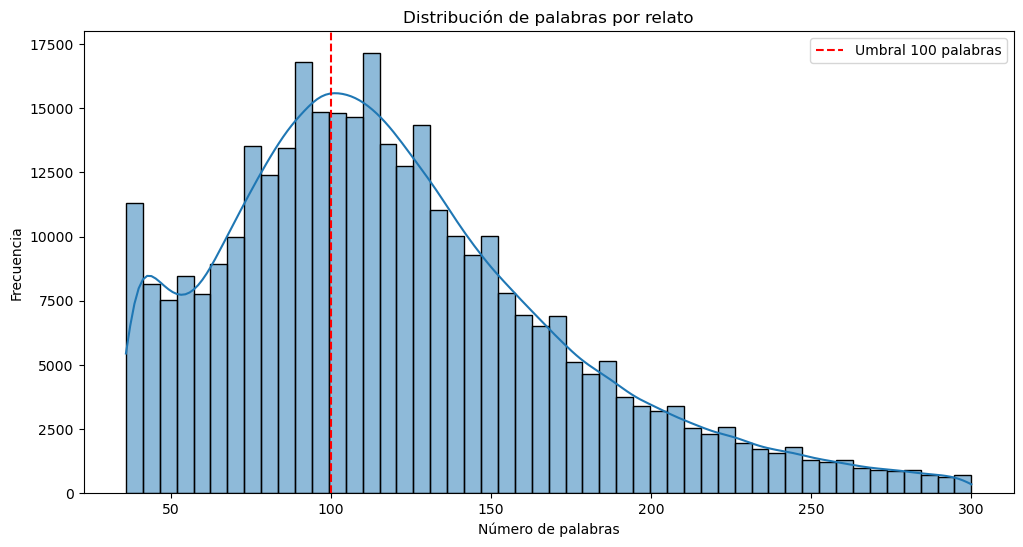

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histograma
plt.figure(figsize=(12, 6))
sns.histplot(ds["train"]["word_count"], bins=50, kde=True)
plt.title("Distribución de palabras por relato")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.axvline(x=100, color="r", linestyle="--", label="Umbral 100 palabras")
plt.legend()
plt.show()

In [38]:
import numpy as np

# Extraer la lista de word_counts directamente desde el Dataset
word_counts = np.array(ds["train"]["word_count"])  # Se carga como array de numpy (eficiente en memoria)

# Calcular estadísticas
stats = {
    "count": len(word_counts),
    "mean": np.mean(word_counts).round(2),
    "std": np.std(word_counts).round(2),
    "min": np.min(word_counts),
    "25%": np.percentile(word_counts, 25).round(2),
    "50%": np.median(word_counts).round(2),
    "75%": np.percentile(word_counts, 75).round(2),
    "max": np.max(word_counts),
}

# Imprimir resultados
print("Estadísticas de word_count:")
for key, value in stats.items():
    print(f"{key}: {value}")

Estadísticas de word_count:
count: 341669
mean: 120.4
std: 53.24
min: 36
25%: 82.0
50%: 112.0
75%: 150.0
max: 300


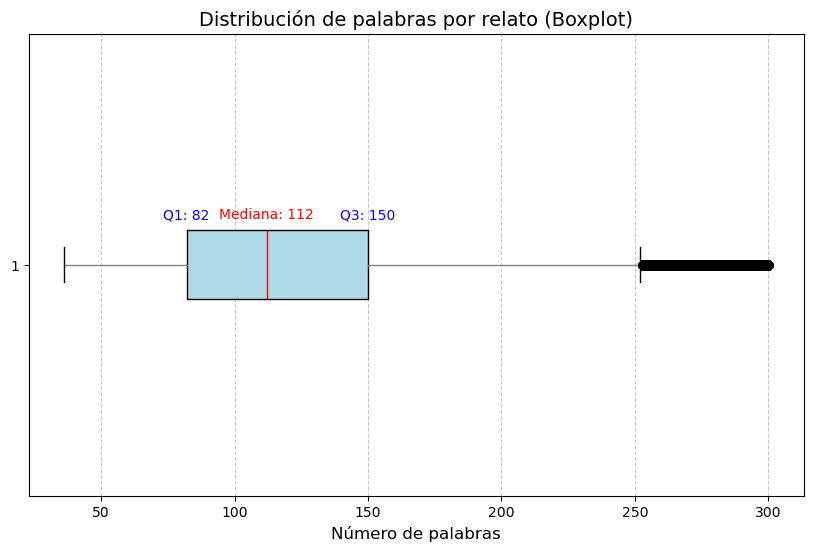

In [39]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    word_counts,
    vert=False,  # Orientación horizontal
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),  # Personalización
    whiskerprops=dict(color="gray"),
    medianprops=dict(color="red"),
)

plt.title("Distribución de palabras por relato (Boxplot)", fontsize=14)
plt.xlabel("Número de palabras", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Opcional: Añadir anotaciones de percentiles
percentiles = np.percentile(word_counts, [25, 50, 75])
plt.text(percentiles[0], 1.1, f"Q1: {percentiles[0]:.0f}", ha="center", color="blue")
plt.text(percentiles[1], 1.1, f"Mediana: {percentiles[1]:.0f}", ha="center", color="red")
plt.text(percentiles[2], 1.1, f"Q3: {percentiles[2]:.0f}", ha="center", color="blue")

plt.show()

## Using Generative AI to create question dataset

1. It seems that it could be a good practice use only samples from more than 100 words. Maybe it could be interesting to consider $82 \leq w \leq150$
2. After that let us try to use some models to get some questions in the format

`{'question':{}, 'answer':{}, 'context':{}}`

In [40]:
# Usar procesamiento por lotes (batched) para mayor velocidad
filtered_ds = ds["train"].filter(
    lambda batch: [82 <= x <= 150 for x in batch["word_count"]], # Apply the condition to each element in the batch
    batched=True,  # Procesa en chunks
    batch_size=1000  # Ajusta según tu RAM
)
filtered_ds

Filter:   0%|          | 0/341669 [00:00<?, ? examples/s]

Dataset({
    features: ['relato', 'labels', 'word_count'],
    num_rows: 174594
})

In [15]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def generate_qa_with_context(text):
    input_text = f"Generate 3 questions and answers based on: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(**inputs, max_length=200)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Ejemplo
result = generate_qa_with_context(ds['train']['relato'][100])
print(result)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

What was the name of the person who threw the money?


In [20]:
text_eng = """It is the case, Mr. Prosecutor, that on August 17, 2018, at approximately 11:00 AM, I left my residence located in the 8 de marzo cooperative, street n, passage e20j, lot 3, number s8 45, sector puente dos, general rumiñahui highway to carry out some payment errands. Upon returning at 1:20 PM, I observed that three individuals were leaving my residence, and outside there was a car parked. Upon entering, I realized that they had taken two LG 4K 65-inch televisions, a Samsung HD 32-inch television, a PlayStation Pro 1TB, a Nintendo Switch, four whiskies, a lot of silver and gold jewelry valued at $3,450 and $40 in cash, for which I am filing this report with the purpose of conducting an investigation of the case. For more information, contact 2605431, 0984860935."""
result = generate_qa_with_context(text_eng)
pprint(result)

'What was the value of the whiskies?'


In [16]:
from transformers import pipeline

# Cargar el modelo y tokenizer
qa_generator = pipeline(
    "text2text-generation",
    model="mrm8488/t5-base-finetuned-question-generation-ap",
    tokenizer="mrm8488/t5-base-finetuned-question-generation-ap"
)

# Función para generar preguntas
def generate_qa(text, max_length=512):
    input_text = f"generate questions: {text}"
    results = qa_generator(
        input_text,
        max_length=max_length,
        num_return_sequences=3,  # Número de preguntas a generar
        num_beams=5,
        temperature=0.7
    )
    return [result["generated_text"] for result in results]

# Ejemplo con tu relato
text = ds["train"][100]["relato"]
questions = generate_qa(text)
print("Preguntas generadas:", questions)

config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based gene

Preguntas generadas: ['question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista general rumiahui a realizar una gestión de pagos al retornar a las 13h', 'question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio ubicado en la cooperativa 8 de marzo calle n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista general rumiahui a realizar una gesti', 'question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio y afuera ase encontraron una gestión de pagos al retornar a las 13h20 puente dos autopista general rumiahui a realizar una gestión de']


In [17]:
pprint(questions)

['question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio n pasaje e20j lote 3 nmero '
 's8 45 sector puente dos autopista general rumiahui a realizar una gestión de '
 'pagos al retornar a las 13h',
 'question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio ubicado en la cooperativa 8 '
 'de marzo calle n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista '
 'general rumiahui a realizar una gesti',
 'question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio y afuera ase encontraron una '
 'gestión de pagos al retornar a las 13h20 puente dos autopista general '
 'rumiahui a realizar una gestión de']


In [21]:
questions = generate_qa(text_eng)
pprint(questions)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


['question: What is the purpose of this report?',
 'question: What is the purpose of this investigation?',
 'question: What was the purpose of this report?']


- There exist the problem of the language. Models used until now seem more efective in English than in Spanish
- I do not agree in using extractive AI to train extractive AI but let us see what happens

In [126]:
preguntas_comunes = [
    "¿Qué objetos fueron robados?",
    "¿En qué fecha ocurrió el incidente?",
    "¿A qué hora sucedió el robo?",
    "¿En qué dirección o entre qué calles sucedió el robo, suceso o incidente?",  # re write there is some error here
    "¿Qué valor en dólares tenían los objetos sustraídos o robados?",
    # "¿Existió intimidación, agresión o violencia?"
]

In [24]:
from transformers import pipeline

# Cargar modelo y tokenizer en español
qa_pipeline = pipeline(
    "question-answering",
    model="PlanTL-GOB-ES/roberta-large-bne-sqac",  # Modelo oficial del PlanTL
    tokenizer="PlanTL-GOB-ES/roberta-large-bne-sqac"
)

# Función para extraer respuestas
def get_answers(context, questions):
    answers = []
    for question in questions:
        result = qa_pipeline(question=question, context=context)
        answers.append({
            "pregunta": question,
            "respuesta": result["answer"],
            "score": round(result["score"], 3)
        })
    return answers

# Ejemplo con tu relato
context = ds["train"][100]["relato"]
respuestas = get_answers(context, preguntas_comunes)

# Imprimir resultados
for respuesta in respuestas:
    pprint(f"Pregunta: {respuesta['pregunta']}")
    pprint(f"Respuesta: {respuesta['respuesta']} (Confianza: {respuesta['score']})\n")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/858k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/516k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


'Pregunta: ¿Qué objetos fueron robados?'
'Respuesta: dos (Confianza: 0.147)\n'
'Pregunta: ¿En qué fecha ocurrió el incidente?'
('Respuesta: el día 17 de agosto del 2018 aproximadamente a las 11h00 '
 '(Confianza: 0.26)\n')
'Pregunta: ¿A qué hora sucedió el hecho?'
'Respuesta: aproximadamente a las 11h00 (Confianza: 0.566)\n'
'Pregunta: ¿Cuál es la dirección donde ocurrió el incidente?'
'Respuesta: la cooperativa 8 de marzo (Confianza: 0.026)\n'
'Pregunta: ¿Qué valor tenían los objetos sustraídos?'
('Respuesta: valorado en 3 450 dolares y 40 dólares en efectivo (Confianza: '
 '0.029)\n')
'Pregunta: ¿Existió intimidación, agresión o violencia?'
'Respuesta: sustraído (Confianza: 0.005)\n'


At this point I think what I ought to do is to work with an instruct model and inference from huggingface in order to save some processing. There I could define the type of output I would want, the model and some other parameters. It is necessary to use a spanish based model or consider translation

### LLAMA
We are going to use an instruct model in order to form questions and answers from the context of the text

In [107]:
def find_start_end_answer(context, answer):
    impossible_flag = False
    start = context.find(answer)
    if start !=-1:
        end = start + len(answer)
    else:
        start = 0
        end = 0
        impossible_flag = True
    return start, end, impossible_flag

find_start_end_answer("hola mi nombre es juancarlos", "juan")

(18, 22, False)

#### JSON Decode Error
Es un error que se presenta cuando la LLM divaga y coloca cualquier texto en la respuesta contaminado de información no entendible

In [117]:
import json
from datetime import datetime

def safe_json_loads(response_str):
    """_summary_

    Args:
        response_str (_type_): _description_
        research_question (_type_): _description_

    Returns:
        json_dictionary: _description_
        boolean: True if error happened
    """
    try:
        return json.loads(response_str)
    except json.JSONDecodeError as e:
        print(f"JSONDecodeError: {e}")
        print("Response string:", response_str)
        return {
            "answer_text": "", 
            "is_impossible": "imposible"
        }

In [130]:
from huggingface_hub import InferenceClient

client = InferenceClient(api_key=token)

model = "meta-llama/Meta-Llama-3-8B-Instruct"
context = ds['train']['relato'][200]

def generate_squad_entry(context, questions, model="meta-llama/Meta-Llama-3-8B-Instruct"):
    answer_list = []
    for question in questions:
        # Formatear el prompt
        prompt = f"""
        Eres un científico de datos que construye un dataset estilo SQuAD en español. 
        Tu tarea es extraer del siguiente contexto la respuesta exacta para la pregunta.

        - Contexto: {context}

        - Pregunta: {question}

        ### Instrucciones:
        1. Responde SOLO con el fragmento exacto del contexto que corresponde a la pregunta.
        2. Si la pregunta no puede responderse con el contexto, escribe 'imposible' en el campo 'is_impossible'. Caso contrario coloca 'respondido'

        """
        # Generar respuesta
        messages = [
            {"role": "system", "content": "Eres un asistente experto en análisis de textos en español y en la generación de datasets"},
            {"role": "user", "content": prompt}
        ]

        response_format = {
            "type": "json",
            "value": {
                "properties": {
                    "answer_text": {"type": "string"},
                    "is_impossible": {"type":"string"},
                },
                "required": ["answer_text", "is_impossible"]
            }
        }

        completion = client.chat_completion(
            model=model,
            messages=messages,
            response_format=response_format,  # type: ignore
            # max_tokens=500
        )

        # Procesar la respuesta
        response_json_str = completion.choices[0].message.content
        # response_json = json.loads(response_json_str)
        response_json = safe_json_loads(response_json_str)
        start_position, end_position, impossible_flag =find_start_end_answer(context=context,
                                                                            answer=response_json['answer_text'])
        dataset_details = {'context':context,
                        'question':question,
                        'answer_start':start_position,
                        'answer_end':end_position,
                        'impossible_find_answer':impossible_flag}
        response_full = {**dataset_details, **response_json}
        answer_list.append(response_full)
    return answer_list

# answ = generate_squad_entry(context=context,questions=preguntas_comunes)
# pprint(answ)


In [131]:
import time
import json
from functools import wraps
from tqdm import tqdm


# Decorador para reintentos y control de tasa
def retry(max_retries=3, delay=5, rate_limit=5):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            attempts = 0
            last_request = 0
            while attempts < max_retries:
                try:
                    # Control de tasa
                    elapsed = time.time() - last_request
                    if elapsed < 60/rate_limit:
                        time.sleep(60/rate_limit - elapsed)
                    
                    result = func(*args, **kwargs)
                    last_request = time.time()
                    return result
                except Exception as e:
                    if "101" in str(e) or "5" in str(e):
                        print(f"Error HTTP ({e}), reintentando...")
                        attempts += 1
                        time.sleep(delay * attempts)
                    else:
                        raise
            raise Exception(f"Fallo después de {max_retries} reintentos")
        return wrapper
    return decorator

In [132]:
@retry(max_retries=2, delay=10, rate_limit=5)
def process_single_context(context, questions):
    return generate_squad_entry(context, questions)

In [133]:
# Función para procesar el dataset completo
def process_full_dataset(dataset, output_file, checkpoint_interval=100):
    # Cargar checkpoint si existe
    try:
        with open(output_file, "r") as f:
            processed_ids = {json.loads(line)["context_id"] for line in f}
        print(f"Checkpoint cargado. Contextos procesados: {len(processed_ids)}")
    except FileNotFoundError:
        processed_ids = set()
    
    # Procesamiento con barra de progreso
    with open(output_file, "a") as f:
        for idx in tqdm(range(len(dataset))):
            context_id = f"context_{idx}"
            if context_id in processed_ids:
                continue
            
            try:
                context = dataset[idx]["relato"]
                results = process_single_context(context, preguntas_comunes)
                
                for res in results:
                    res["context_id"] = context_id
                    f.write(json.dumps(res, ensure_ascii=False) + "\n")
                
                # Guardar checkpoint
                if idx % checkpoint_interval == 0:
                    f.flush()
                    print(f"Checkpoint guardado en contexto {idx}")
                    
            except Exception as e:
                print(f"Error crítico en contexto {idx}: {str(e)}")
                with open("errores.log", "a") as err_log:
                    err_log.write(f"{context_id}\t{str(e)}\n")
    
    print("Procesamiento completo!")

In [135]:
174594*5/20000

43.6485

In [136]:
# Ejecutar en el dataset
# dataset = filtered_ds.select(range(50))
dataset = filtered_ds
output_file = "./dataset/dataset_squad.json"
checkpoint_interval = 1000  # Guardar cada 100 contextos procesados

process_full_dataset(dataset=dataset, 
                     output_file=output_file, 
                     checkpoint_interval=checkpoint_interval)

  0%|          | 1/174594 [00:00<39:42:36,  1.22it/s]

Checkpoint guardado en contexto 0


  0%|          | 37/174594 [00:19<23:43:32,  2.04it/s]

JSONDecodeError: Expecting ',' delimiter: line 1 column 7257 (char 7256)
Response string: {"answer_text": "un playstation 4 pro edicion spiriman limitado con sus respectivos controles uno rojo y el otro negro un disco de almacenamiento extraíble de 4 tb 01 memori fhash de 64 gb y tres videos juegos", "is_impossible": "} (respondido) (El objeto robado fue un playstation 4 pro edición Spiriman limitado con sus respectivos controles, un disco de almacenamiento extraíble de 4 TB, 01 memorí fhash de 64 gb y tres videos juegos) Srita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stitia.28147.st1479.668612 Srita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stita.28147.st1479.668612stitia.28147.st1479.668612 SrRoss Sr S3475Terminal Terminal Terminal T

  0%|          | 66/174594 [00:35<24:48:00,  1.95it/s]

...

  1%|          | 1001/174594 [3:21:25<209:40:51,  4.35s/it]

Checkpoint guardado en contexto 1000


  1%|          | 1040/174594 [3:24:25<559:47:05, 11.61s/it]

JSONDecodeError: Expecting ',' delimiter: line 1 column 3120 (char 3119)
Response string: {"answer_text": "20 00 en efectivo", "is_impossible": "} (respuedo) tomando el contexto se puede ver que el valor en efectivo sustraído era 20 00 que aproximadamente equivaldría a 20 US dólares por la tasa de cambio en ese momento. El tamaño de la respuesta se ajusta a los requisitos del formato SQuAD. La fecha mencionada es 9 de noviembre del 2017, la tasa de cambio de la época era aproximadamente 1 USD equivalente a 18.3 ARS. Lovolario Reveré. EクトECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTECTE

  1%|          | 1544/174594 [3:59:48<204:45:40,  4.26s/it]

It seems that it was possible to build using this methodology a total of 1544 out of 174594 samples. Take in consideration that for each case 5 questions are formulated and answered. However, this dataset could be small to fine tune?